# Cluster results — locations and focal mechanisms

A single, cluster-parameterized notebook to view a cluster's **located catalog** and its
**focal mechanisms together**. Set the params below and run top to bottom.

Focal mechanisms require a **phasenet_plus** run (the PhaseNet+ picker emits first-motion polarity
+ S/P amplitude that SKHASH needs); point `RUN_SUFFIX` at that run's output tree. Locations alone
work for any picker.

In [1]:
%matplotlib inline
import os, sys
# Assumes the notebook runs from pipeline/notebooks/ ; otherwise set PYTHONPATH=<repo root>.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pipeline import config, viz

# ------------------------------- PARAMS (edit & re-run) -------------------------------
CLUSTER    = "geochang"        # gwangyang | kimcheon | jangsung | gyeongju
RUN_SUFFIX = ""          # output tree = runs/<cluster><suffix>; "" = the default run
VELMODEL   = "kim1983"          # velocity model whose .sum / mechanisms to show
N_BOOT     = 1000               # bootstrap replicas for the 95% location error bars (cached)
BOOT_SEED  = 0                  # bootstrap RNG seed (reproducible)
FRAME_FROM = "auto"             # fault-frame plane for sections 4 & 5:
                                #   "auto"      — mainshock nodal plane (NP1/NP2 matched to SVD strike)
                                #                 if a grade-A/B mechanism exists; else SVD fallback.
                                #   "svd"       — always use the SVD best-fit plane of the relocated cloud.
                                #                 Use this when the mechanism is unreliable (small mainshock,
                                #                 grade C/D) but the relocation forms a clear lineation
                                #                 (Uiseong-type cases).
                                #   "mechanism" — always use the mainshock nodal plane (raises if absent).

# Bootstrap "under-constrained" drop thresholds — events failing any of these are dropped from
# every dt.cc/dt.ct plot (and from the section/3-D views). Symmetric horizontal + vertical caps;
# set BOOT_DROP_VERT_KM=None to disable vertical filtering and keep the v1.3.0 behaviour.
BOOT_DROP_HORIZ_KM = 0.1        # km, max 95% horizontal half-width √(ex95²+ey95²)
BOOT_DROP_VERT_KM  = 0.1        # km, max 95% vertical half-width ez95 (None disables)

viz.BOOT_DROP_HORIZ_KM = BOOT_DROP_HORIZ_KM
viz.BOOT_DROP_VERT_KM  = BOOT_DROP_VERT_KM

# Reference-mechanism selection for sections 4 & 5 (drives the beachball, the section plane
# when FRAME_FROM="auto"/"mechanism", and the title string).
#   "highest_quality"  — pick the best-graded mechanism first (A → B → C → D); within the
#                        best-available grade, largest magnitude wins. So a grade-A M1.2 is
#                        preferred to a grade-B M1.4 — quality always beats magnitude.
#   "largest_magnitude" — legacy v1.3.1 behaviour: pick the largest magnitude inside the
#                         cfg.fm_quality_keep pool (typically A+B unified). Use this if you
#                         specifically want the mainshock regardless of grade.
MECH_SELECT = "highest_quality"

cfg0 = config.load_cluster(CLUSTER)
cfg  = config.tune(cfg0, output_root=os.path.join(config.RUNS_ROOT, f"{CLUSTER}{RUN_SUFFIX}")) \
       if RUN_SUFFIX else cfg0
print(f"{cfg.region}: outputs -> {cfg.output_root}")

Geochang: outputs -> /home/msseo/works/15.PocketQuake/external/korea-cluster-relocation/pipeline/runs/geochang


## 1. Locations

Three location stages, each with fewer events than the last: **`.sum`** is every event HYPOINVERSE
locates absolutely; **dt.ct** is the HypoDD catalog relocation, which keeps only events with enough
catalog differential-time links (isolated events drop); **dt.cc** is the HypoDD cross-correlation
relocation, which further keeps only events whose waveforms correlate well. **dt.cc is the high-end
product** (errors of metres vs tens of metres for dt.ct) and is the headline relocation below. Counts
shrink `.sum ≥ dt.ct ≥ dt.cc` but not strictly — each HypoDD run re-clusters independently.

In [2]:
display(viz.relocation_counts(cfg, VELMODEL))

,stage,events
0,.sum (absolute),4
1,dt.ct (catalog),3
2,"dt.cc (cross-corr, high-end)",3


### Location uncertainty — bootstrap 95%

HypoDD's own (LSQR a-posteriori) errors badly **underestimate** the true relative-location uncertainty.
We instead estimate it by **bootstrapping the differential-time data** (the relocation backend's
`bootstrap_relocation` — Fortran hypoDD or relocDD-py, same resampling/percentile procedure):
pool all dt observations, resample with replacement, regroup, and re-run HypoDD `N_BOOT` times with the
inversion held fixed (the calibrated `hypoDD.inp`). Each replica is **seeded from the converged relocation**
(so the bar measures the data-driven spread *around the solution*, not the ability to re-converge from a
poor initial absolute location) and **median-aligned**; the per-event **2.5–97.5 percentile half-width** of
the X/Y/Z scatter is the **95% error bar** drawn on every location / section / 3-D plot below (percentile,
not σ — robust to the heavy tail of the global resample). It is cached + seeded (reproduces exactly; first
run is slow, then instant). The plots also **drop events the bootstrap flags as under-constrained**
(`viz._boot_underconstrained`) and note the count, and **circles scale by KMA local magnitude**.

In [3]:
from pipeline.core import hypodd, sumio
import numpy as _np
# Bootstrap engine follows the relocation backend: relocDD-py re-inverts its own clusters
# (pure-Python path), Fortran hypoDD re-inverts the Fortran ones. Same resampling/percentile
# procedure either way (relocdd_py_backend.bootstrap_relocation mirrors hypodd's).
if getattr(cfg, "reloc_backend", "hypodd") == "relocdd_py":
    from pipeline.core import relocdd_py_backend as _rddpy
    _bootstrap = _rddpy.bootstrap_relocation
else:
    _bootstrap = hypodd.bootstrap_relocation
_rows = []
for _lab, _br in (("dt.ct", "dtct"), ("dt.cc", "dtcc")):
    _bdir = config.dtct_dir(cfg) if _br == "dtct" else config.dtcc_dir(cfg)
    if not os.path.exists(os.path.join(_bdir, "hypoDD.reloc")):
        continue
    _bb = _bootstrap(cfg, branch=_br, n=N_BOOT, seed=BOOT_SEED)   # cached
    _rl = sumio.read_reloc(os.path.join(_bdir, "hypoDD.reloc"))
    _rows.append(dict(branch=_lab, events=len(_rl), n_with_CI=int(_bb.ex95.notna().sum()),
                      ex95_boot_m=_np.nanmedian(_bb.ex95), ey95_boot_m=_np.nanmedian(_bb.ey95),
                      ez95_boot_m=_np.nanmedian(_bb.ez95),
                      ex_int_m=_rl.ex.median(), ey_int_m=_rl.ey.median(), ez_int_m=_rl.ez.median()))
display(pd.DataFrame(_rows).round(1))
print("Median 95% bootstrap half-widths (…_boot_m) vs HypoDD internal a-posteriori errors (…_int_m), metres.")

,branch,events,n_with_CI,ex95_boot_m,ey95_boot_m,ez95_boot_m,ex_int_m,ey_int_m,ez_int_m
0,dt.ct,3,3,21.5,24.3,152.7,9.7,9.4,41.6
1,dt.cc,3,3,1.8,2.0,18.8,0.3,0.3,1.7


Median 95% bootstrap half-widths (…_boot_m) vs HypoDD internal a-posteriori errors (…_int_m), metres.


Per-event diagnostic — the dt.cc events with the largest 95% horizontal error, with their CC/CT link
counts and `n_boot` (replicas where the event relocated). A large bar with **plenty of links** means the
event is poorly *determined* (geometry — e.g. shallow + one-sided coverage), not poorly *measured*; such
events are dropped from the plots below (`viz._boot_underconstrained`).

The `horiz_ok` / `vert_ok` / `nboot_ok` flags break down WHY each event was dropped. The drop
thresholds are the `BOOT_DROP_*_KM` parameters in the params cell — relax them if your cluster has
genuinely larger uncertainty (e.g. set `BOOT_DROP_VERT_KM=0.5` for shallow swarms where 100 m depth
control is unrealistic).

In [4]:
_bdir = config.dtcc_dir(cfg)
if os.path.exists(os.path.join(_bdir, "hypoDD.reloc")):
    _bb = _bootstrap(cfg, branch="dtcc", n=N_BOOT, seed=BOOT_SEED)
    _rl = sumio.read_reloc(os.path.join(_bdir, "hypoDD.reloc"))[["id","nccp","nccs","nctp","ncts"]]
    _t = _rl.merge(_bb[["id","n_boot","ex95","ey95","ez95"]], on="id")
    _t["horiz95_m"] = _np.hypot(_t.ex95, _t.ey95)
    _t["ez95_m"]   = _t.ez95
    # Break down the drop reason for each event
    _t["horiz_ok"] = _t.horiz95_m <= viz.BOOT_DROP_HORIZ_KM * 1000
    _t["vert_ok"]  = (viz.BOOT_DROP_VERT_KM is None) | (_t.ez95_m <= (viz.BOOT_DROP_VERT_KM or 1e9) * 1000)
    _t["nboot_ok"] = _t.n_boot >= viz.BOOT_DROP_MIN_NBOOT_FRAC * N_BOOT
    _t["dropped"]  = _t.id.isin(viz._boot_underconstrained(cfg, "dt.cc"))
    display(_t.sort_values("horiz95_m", ascending=False)
            [["id","nccp","nccs","nctp","ncts","n_boot","horiz95_m","ez95_m",
              "horiz_ok","vert_ok","nboot_ok","dropped"]]
            .head(6).round(1).reset_index(drop=True))

,id,nccp,nccs,nctp,ncts,n_boot,horiz95_m,ez95_m,horiz_ok,vert_ok,nboot_ok,dropped
0,200004,0,0,0,0,990,3.3,18.8,True,True,True,False
1,200003,0,0,0,0,990,2.9,38.8,True,True,True,False
2,200002,0,0,0,0,990,2.1,9.1,True,True,True,False


### Final relocation table — locations + bootstrap 95% errors

`viz.location_table` is the headline deliverable: one neat row per event with the dt.cc location
(`latitude`/`longitude`/`depth_km`), KMA local `magnitude`, the bootstrap **95% half-widths**
`ex95_m`/`ey95_m`/`ez95_m` (E/N/Z metres), `n_boot` (replicas the event relocated in), the HypoDD
inter-event link counts (`cc_links`/`ct_links`), and an `under_constrained` flag (the bootstrap-flagged
events the plots drop). It also writes **`final_locations.csv`** to the dt.cc run directory. Below it is
styled for the notebook — error columns shaded (darker = larger), under-constrained rows tinted red.

In [5]:
loc = viz.location_table(cfg)                       # also writes <dt.cc dir>/final_locations.csv
print(f"{len(loc)} events — written to final_locations.csv in the dt.cc run directory")
_fmt = {c: "{:.1f}" for c in ("magnitude", "ex95_m", "ey95_m", "ez95_m")}
_fmt.update({"latitude": "{:.5f}", "longitude": "{:.5f}", "depth_km": "{:.3f}"})
_sty = (loc.style.format(_fmt, na_rep="—")
        .background_gradient(subset=["ex95_m", "ey95_m", "ez95_m"], cmap="OrRd")
        .apply(lambda r: ["background-color:#ffdede" if r.under_constrained else "" for _ in r], axis=1)
        .set_caption("Final dt.cc relocation with bootstrap 95% errors (m); "
                     "red rows = under-constrained (dropped from the plots)")) if len(loc) else None
display(_sty if _sty is not None else "No dt.cc reloc for this run.")

3 events — written to final_locations.csv in the dt.cc run directory


,event_id,origin_time,latitude,longitude,depth_km,magnitude,ex95_m,ey95_m,ez95_m,n_boot,cc_links,ct_links,under_constrained
0,20211215130214,2021-12-15 13:02:15,35.79060,127.80884,8.808,2.3,1.6,1.4,9.1,990,0,0,False
1,20221109093200,2022-11-09 09:32:00,35.79067,127.80857,8.861,1.2,1.8,2.2,38.8,990,0,0,False
2,20230120173441,2023-01-20 17:34:41,35.79063,127.80849,8.791,1.4,2.6,2.0,18.8,990,0,0,False


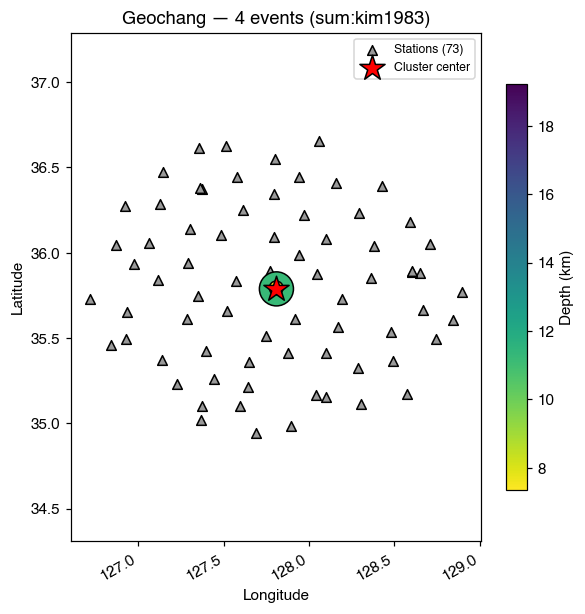

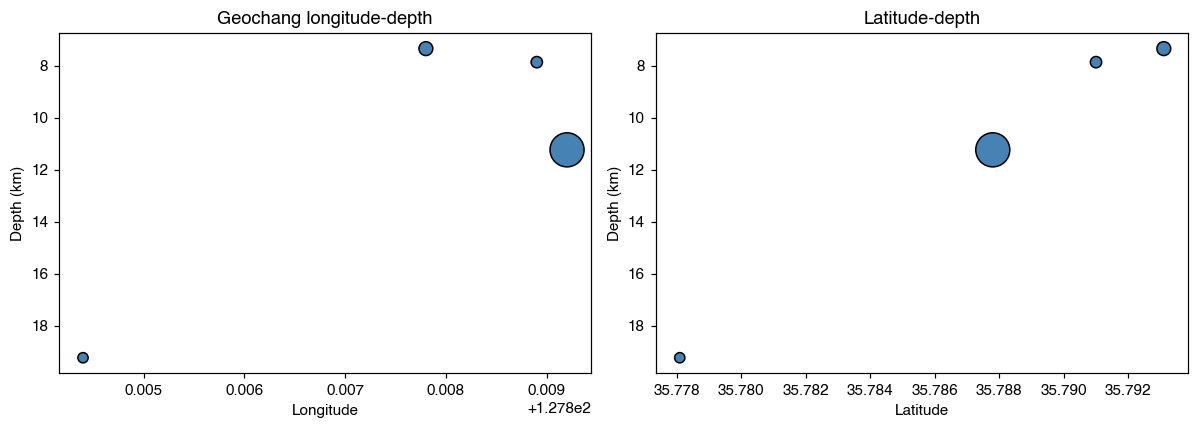

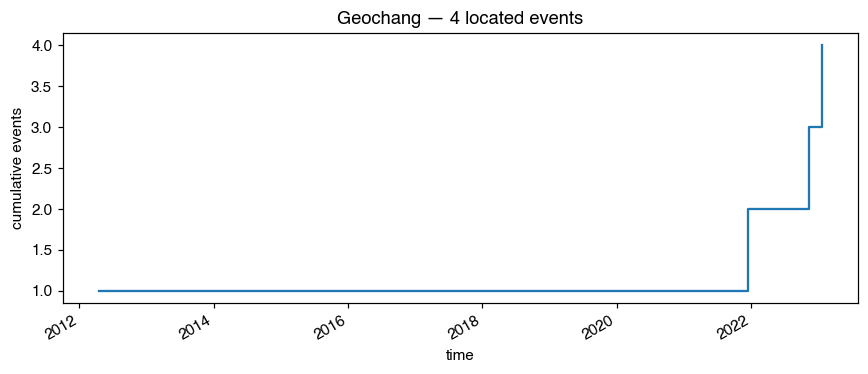

In [6]:
viz.map_catalog(cfg, velmodel=VELMODEL, source="sum"); plt.show()
viz.depth_sections(cfg, velmodel=VELMODEL, source="sum"); plt.show()
viz.cumulative_events(cfg, velmodel=VELMODEL); plt.show()

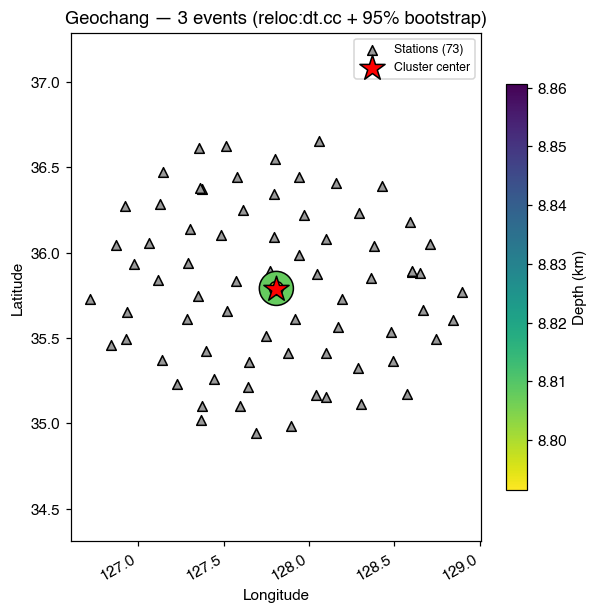

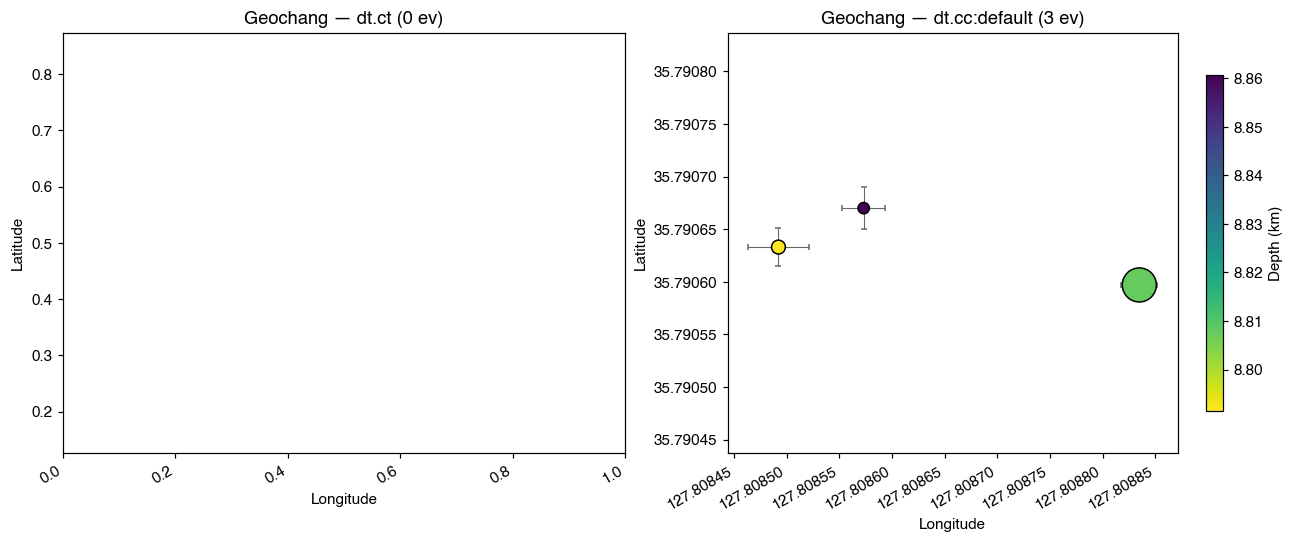

In [7]:
# headline relocated catalog (dt.cc if present, else dt.ct) — bootstrap-filtered
if os.path.exists(os.path.join(config.dtct_dir(cfg), "hypoDD.reloc")):
    viz.map_catalog(cfg, velmodel=VELMODEL, source="reloc"); plt.show()
    if os.path.exists(os.path.join(config.dtcc_dir(cfg), "hypoDD.reloc")):
        viz.compare_epicenters(cfg, velmodel=VELMODEL); plt.show()   # dt.ct vs dt.cc
else:
    print("No HypoDD reloc for this run — showing absolute (.sum) locations only.")

### Summary view — all events, no bootstrap filtering

A clean overview for presentation: every event in the catalog, the bootstrap-filtered ones as
filled depth-coloured circles (from the dt.cc reloc), and the events that HypoDD's clustering
or the bootstrap dropped overlaid as **hollow squares** at their HypoInverse (.sum) absolute
location. Bootstrap error bars are suppressed — for those, see the headline plot above.

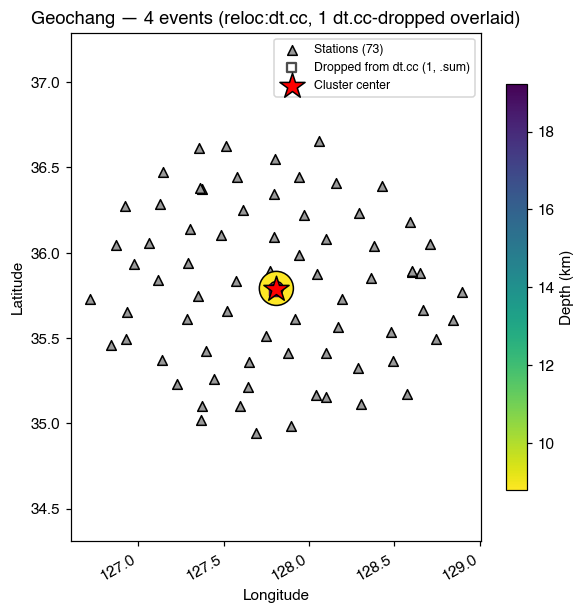

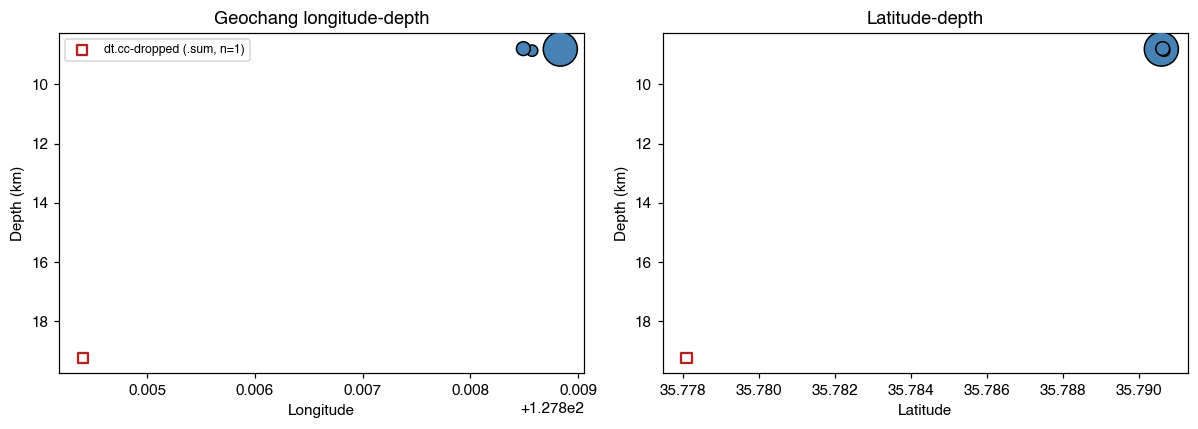

In [8]:
# all-events summary view (include the dt.cc-dropped + bootstrap-under-constrained,
# without bootstrap error bars — a clean representative plot for the whole catalog).
if os.path.exists(os.path.join(config.dtcc_dir(cfg), "hypoDD.reloc")):
    viz.map_catalog(cfg, velmodel=VELMODEL, source="reloc",
                    include_all=True, show_errors=False); plt.show()
    viz.depth_sections(cfg, velmodel=VELMODEL, source="reloc",
                       include_all=True, show_errors=False); plt.show()

### HypoDD link map — inter-event differential-time connectivity

Each line is a HypoDD event pair, drawn between the two relocated epicenters and **coloured by
the number of differential-time observations** (P + S combined) for that pair — the strongest
doublets are the brightest and thickest lines. Left panel uses absolute travel-time differences
(`dt.ct`, catalog phase picks); right panel uses the cross-correlation differential times
(`dt.cc`) above the configured cc-threshold. Sparse links (a single weak obs) are kept by
default; pass `min_obs=N` to declutter big clusters.

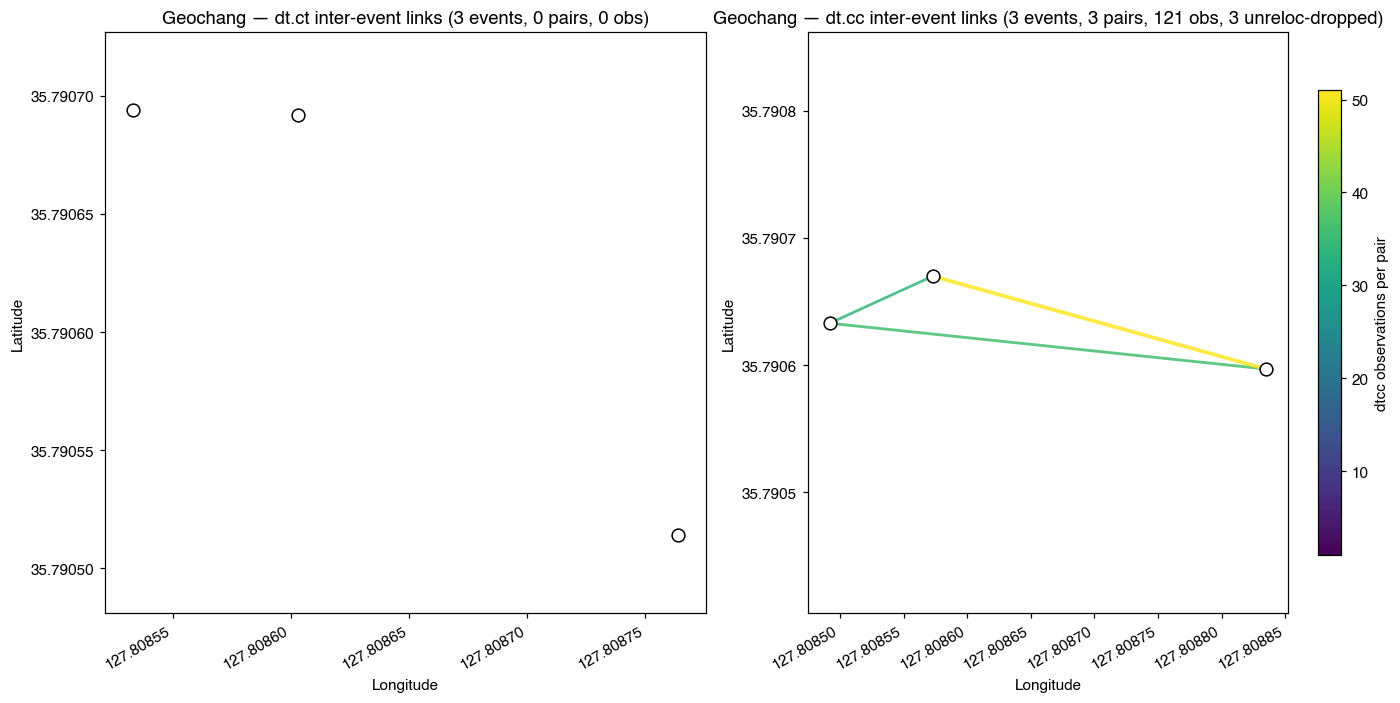

In [9]:
# inter-event link map for both HypoDD branches (cc on the right when present).
viz.link_maps(cfg, velmodel=VELMODEL); plt.show()

## 2. Picks and first-motion polarity

PhaseNet+ picks carry a first-motion **polarity** (up/down) — the input to the focal-mechanism inversion.
`plot_3c` shows the three components with P (red) / S (blue) and the P polarity marked on the vertical;
`plot_polarities` is a P-aligned first-motion record section sorted by azimuth (red = up, blue = down),
i.e. the up/down-vs-azimuth pattern that constrains the mechanism.

Sample event: 20221109093200


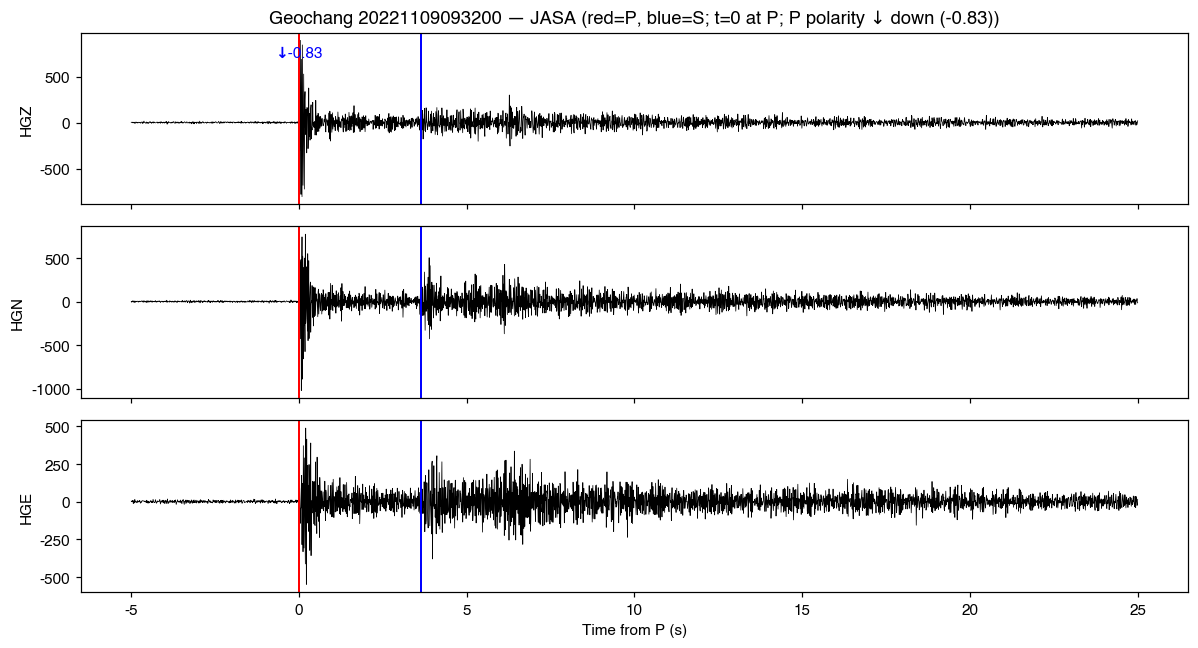

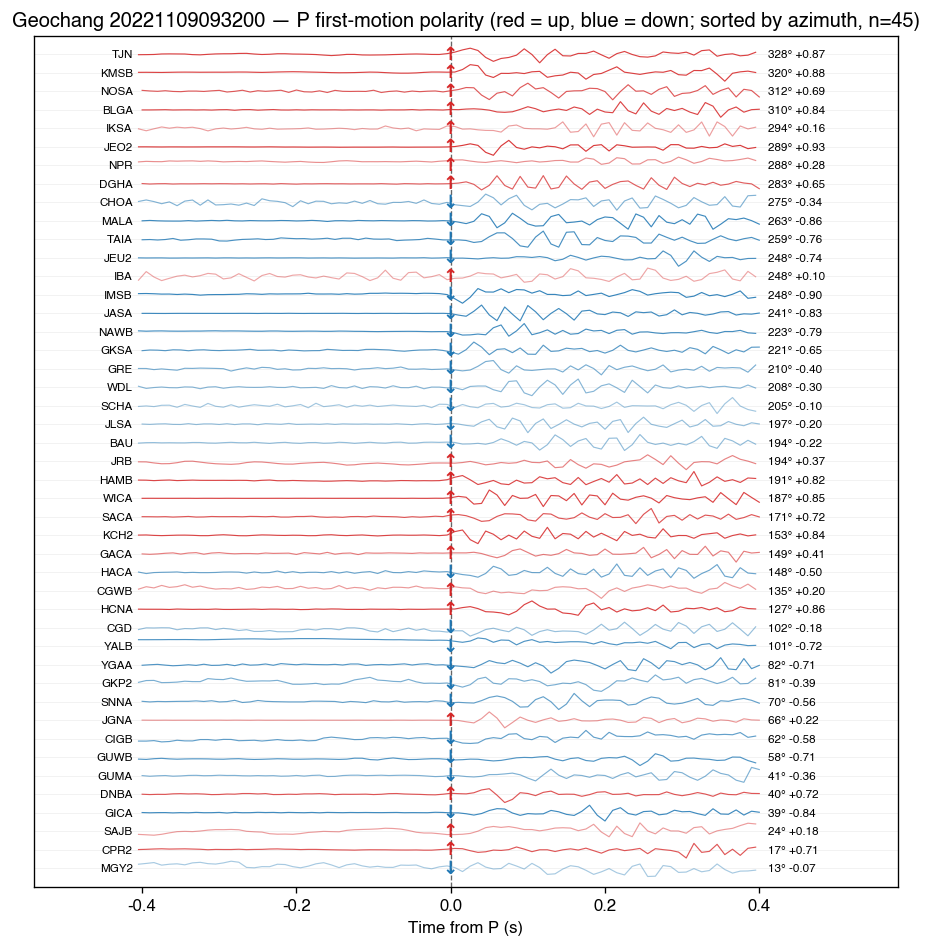

In [10]:
# a representative event: the best-quality mechanism, else the first picks CSV
import glob as _glob
_tbl = viz.mechanism_table(cfg, VELMODEL)
if len(_tbl):
    SAMPLE_EVENT = str(_tbl.sort_values("quality").iloc[0].event_id)
else:
    _pf = sorted(_glob.glob(os.path.join(config.picks_dir(cfg), "*_picks.csv")))
    SAMPLE_EVENT = os.path.basename(_pf[0]).split("_")[0] if _pf else None
print("Sample event:", SAMPLE_EVENT)
if SAMPLE_EVENT is None:
    print("(no mechanism table and no picks found — skipping the sample 3-C / polarity plots)")
else:
    viz.plot_3c(cfg, SAMPLE_EVENT); plt.show()
    viz.plot_polarities(cfg, SAMPLE_EVENT); plt.show()

### Picks QC — distance record section per event

For every event, the **distance record section** (`viz.plot_record_section`) shows Z-component traces
ordered by epicentral distance with the AI picks (P=red, S=blue) overlaid as vertical ticks, alongside the
predicted P/S moveout curves from `cfg.pick_window["vp"]`/`["vs"]` (red/blue dashed). The defaults use the
picker's own thresholds — `cfg.p_threshold` / `cfg.s_threshold` — so every emitted pick appears, including
weak ones. **Picks that drift off the predicted moveout line are the diagnostic** for a depth-mis-matched
picking window or noise-contaminated picks.

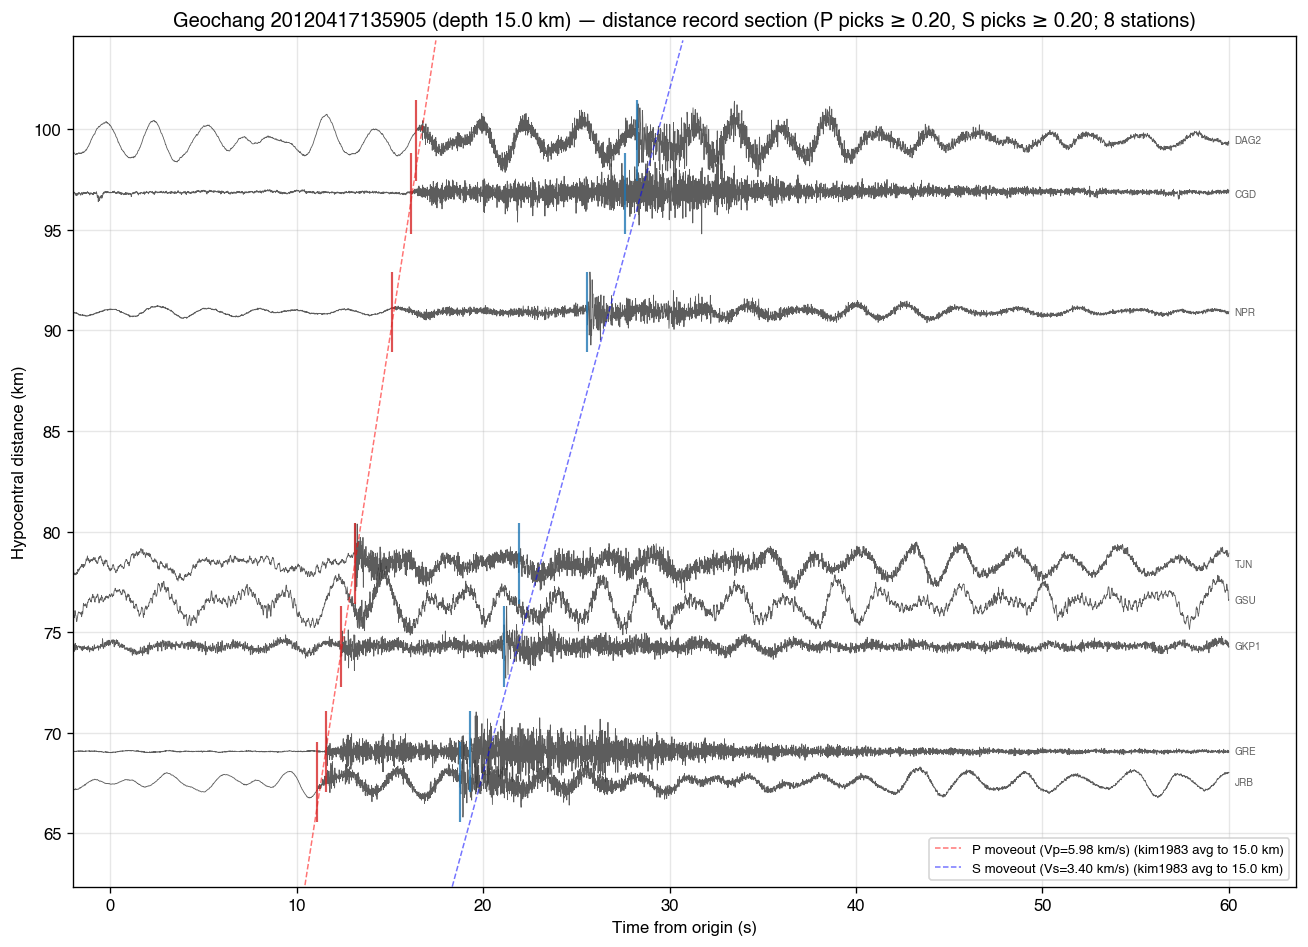

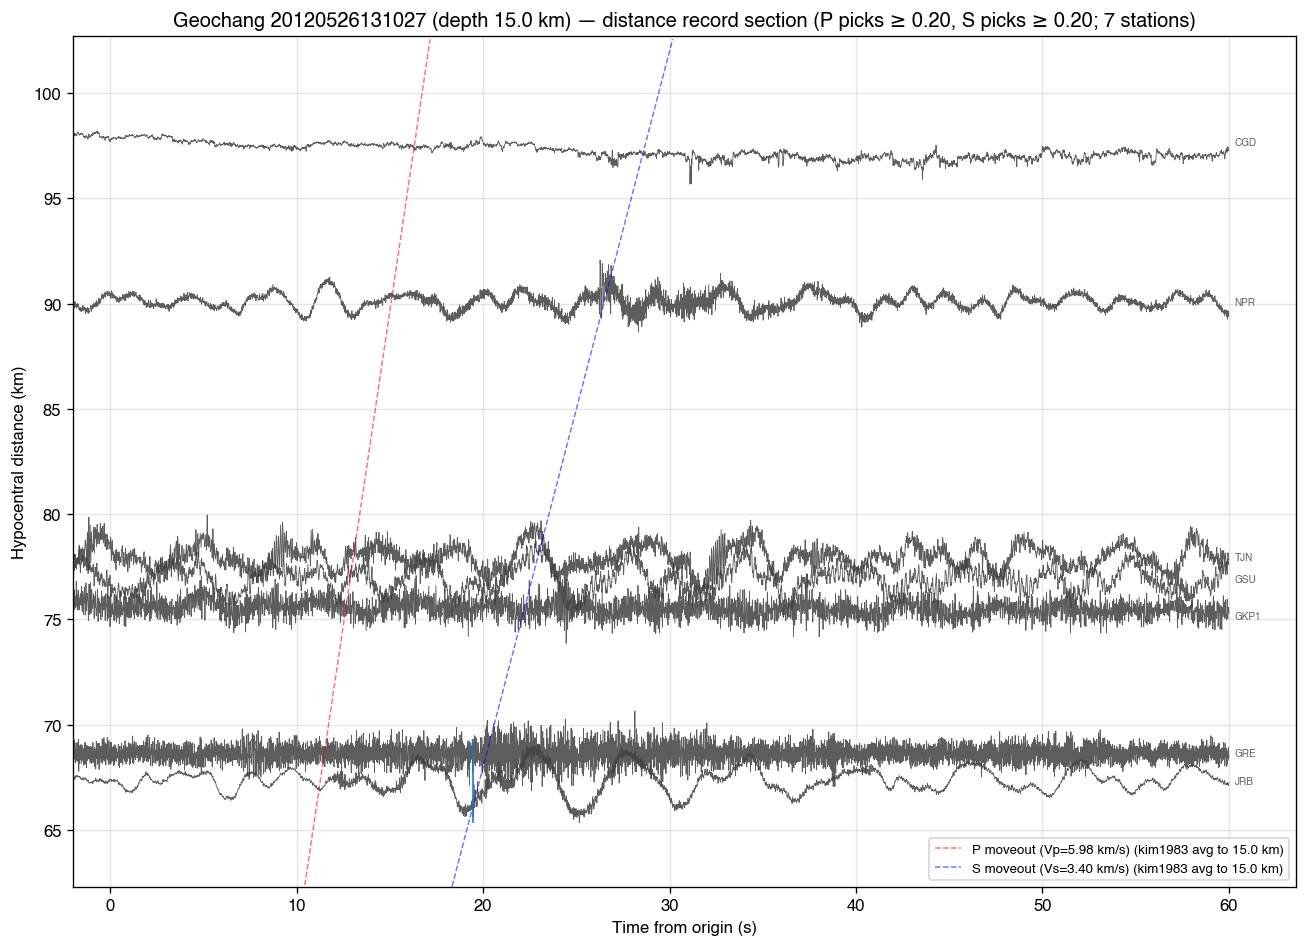

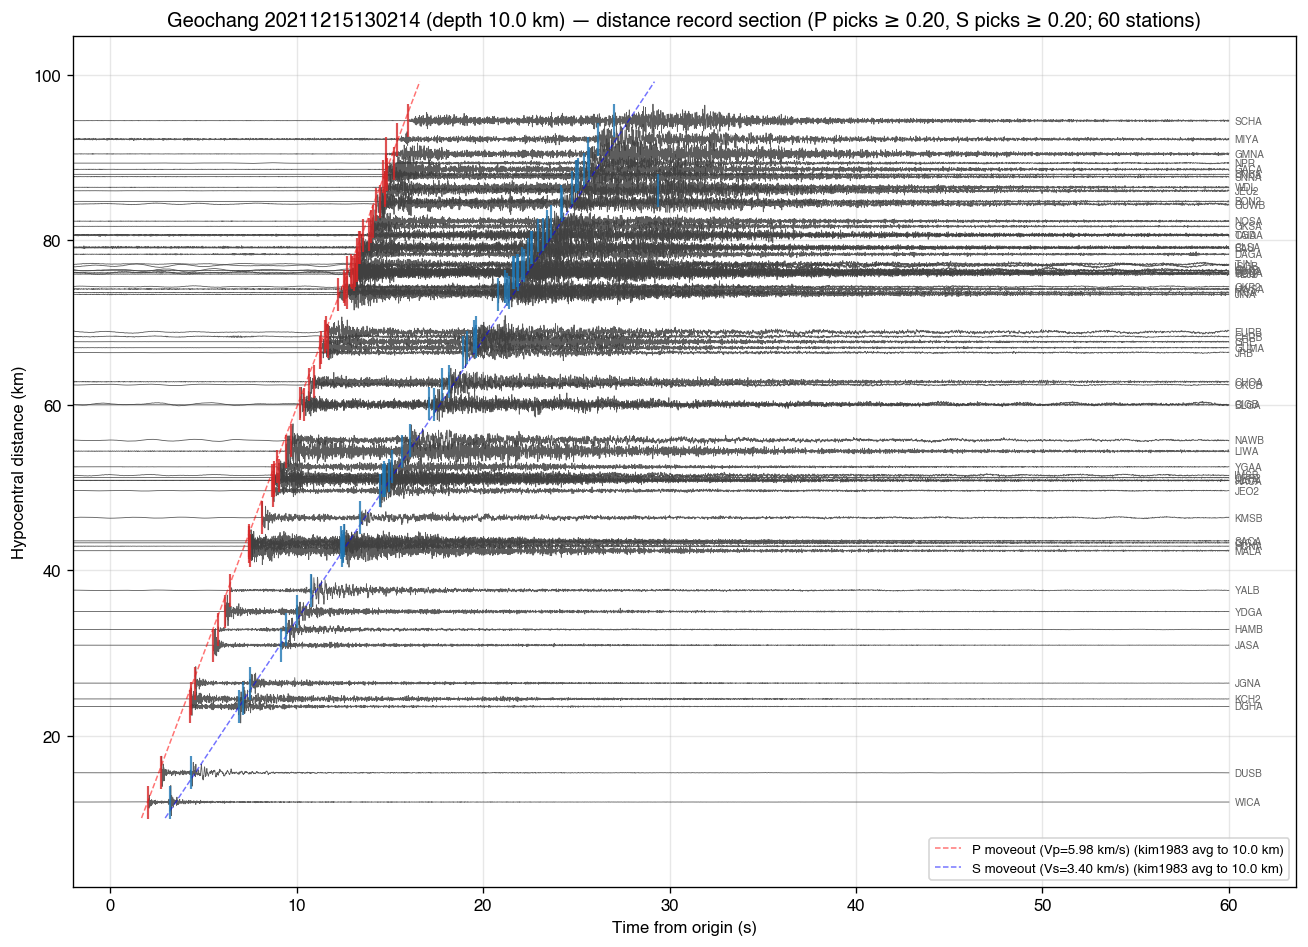

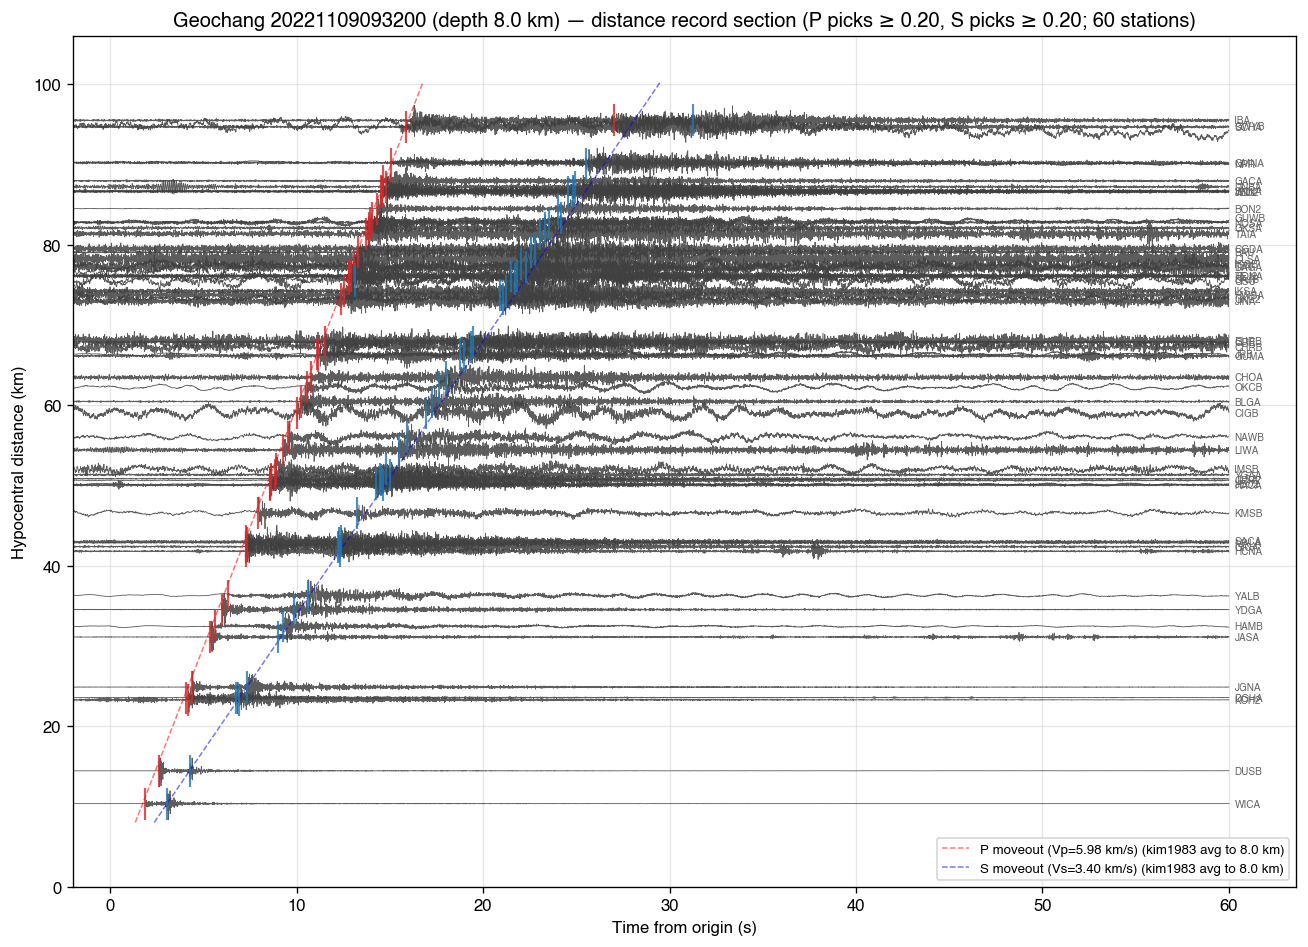

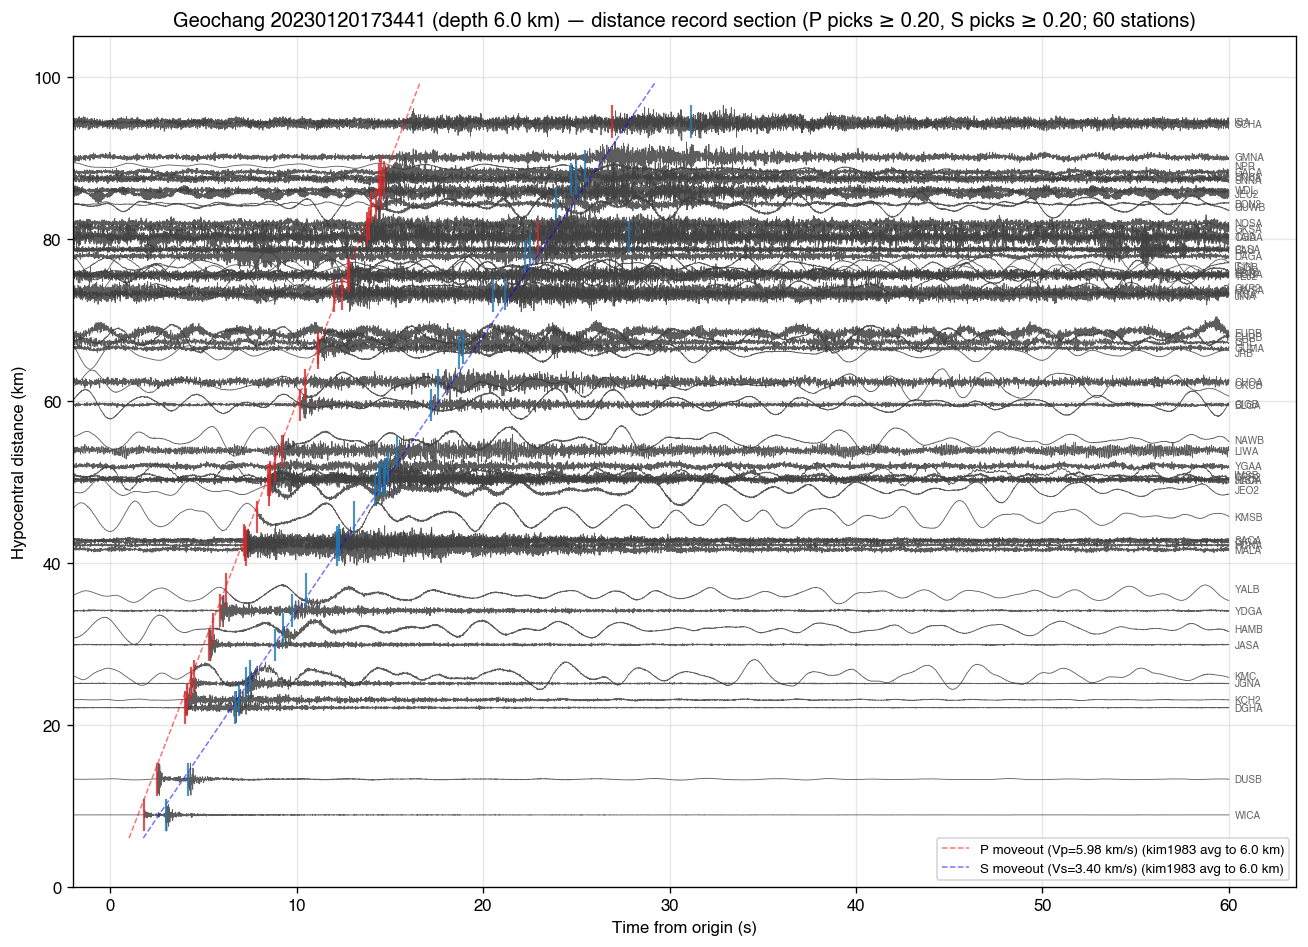

In [11]:
# one record section per event in the catalog
import glob as _glob
_pfs = sorted(_glob.glob(os.path.join(config.picks_dir(cfg), "*_picks.csv")))
for _pf in _pfs:
    _eid = os.path.basename(_pf).split("_")[0]
    viz.plot_record_section(cfg, _eid); plt.show()

## 3. Focal mechanisms

The table is one row per event (best quality kept) and lists **both nodal planes** —
`strike/dip/rake` is the SKHASH-reported plane (NP1) and `strike2/dip2/rake2` its conjugate
(NP2, via obspy `aux_plane`); a double-couple is fully described by either, and the fault is one
of the two. `map_mechanisms` shows the **locations and focal mechanisms together**: located
epicenters as depth-coloured dots, with the high-confidence (quality A/B) beachballs offset on a
ring around the cluster (leader line to each true epicenter) so a tight cluster stays legible.

,event_id,quality,strike,dip,rake,strike2,dip2,rake2,fault_plane_uncertainty,num_p_pol,num_sp_ratios,azimuthal_gap,sta_distribution_ratio,origin_depth_km
0,20221109093200,A,23.2,83.5,178.0,113.4,88.0,6.5,15.4,41,40,30.5,77.6,7.87
1,20211215130214,A,19.0,85.6,-178.9,288.9,88.9,-4.4,18.7,65,71,16.2,74.3,11.24
2,20230120173441,B,28.4,77.6,176.4,119.2,86.5,12.4,11.5,23,17,31.3,77.2,7.35


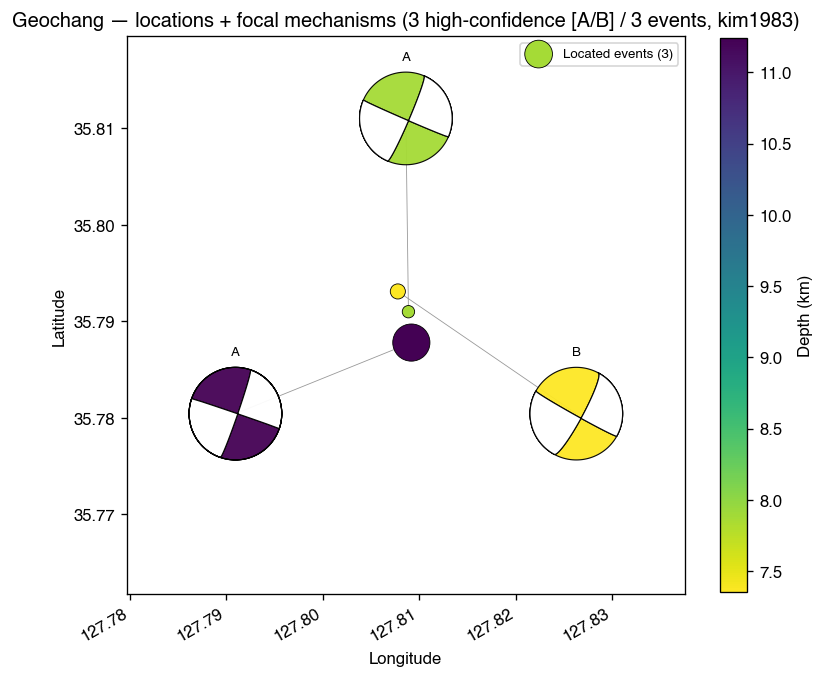

In [12]:
# guard: focal_mechanism stage may not have run (e.g. ph2dt failed upstream)
_FM_OK = os.path.exists(config.fm_mech_csv(cfg, VELMODEL))
tbl = viz.mechanism_table(cfg, VELMODEL) if _FM_OK else pd.DataFrame()
if not _FM_OK:
    print(f"(no mechanisms.csv yet — run the focal_mechanism stage for {CLUSTER} with picker_weights='phasenet_plus')")
else:
    display(tbl)
    viz.map_mechanisms(cfg, VELMODEL); plt.show()

### Per-event beachball gallery (polarities + S/P amplitude ratios)

`viz.plot_custom_beachball` overlays SKHASH's per-station inversion data on the obspy beach
rendering — **filled red triangles** are upward first-motion picks (compressional, should land
in the gray quadrants), **blue triangles** are downward (dilatational, white quadrants), with
marker size ∝ polarity weight `|p_polarity|`. The small offset **circles** are coloured by
log₁₀ of the S/P amplitude ratio (viridis, clipped to ±2). The visible mismatches are the
polarity-misfit % SKHASH reports in the table above; a clean fit (low misfit) shows almost all
triangles on the model-predicted side of the nodal planes.

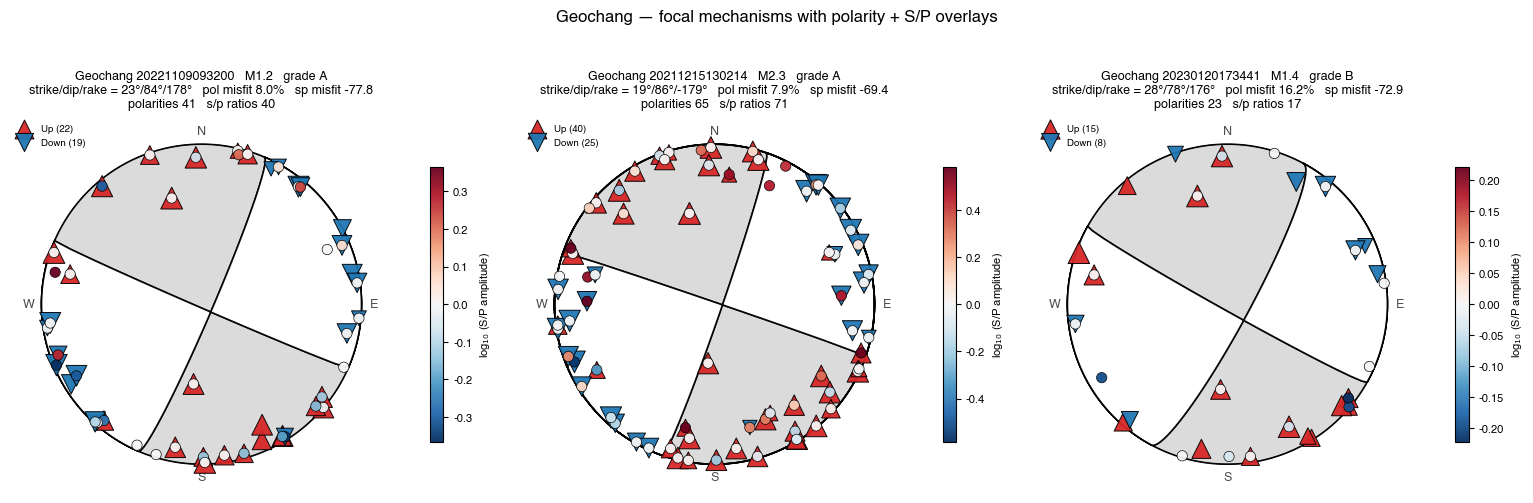

In [13]:
# per-event beachball gallery (polarity + S/P overlays via viz.plot_custom_beachball)
if not _FM_OK:
    print("(no mechanisms.csv — skipping beachball gallery)")
else:
 # prefer the high-confidence (A/B) events; if none, fall back to the best-graded ones so
 # any solution is at least visible
 hi   = tbl[tbl.quality.isin(cfg.fm_quality_keep)] if len(tbl) else tbl
 sel  = (hi if len(hi) else tbl.sort_values("quality")).head(9)
 ids  = list(sel.event_id.astype(str))
 if ids:
     ncol = min(3, len(ids)); nrow = (len(ids) + ncol - 1) // ncol
     fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 5.6 * nrow), squeeze=False)
     for ax in axes.ravel():
         ax.axis("off")
     for ax, eid in zip(axes.ravel(), ids):
         viz.plot_custom_beachball(cfg, eid, velmodel=VELMODEL, ax=ax)
     fig.suptitle(f"{cfg.region} — focal mechanisms with polarity + S/P overlays",
                  fontsize=12, y=1.0)
     plt.tight_layout(); plt.show()
 else:
     print("No mechanisms to plot (needs a phasenet_plus focal_mechanism run).")

## 4. Seismicity in fault coordinates

`fault_sections` rotates the dt.cc relocated catalog into the fault frame and shows four panels:
a **fault-plane map view** (with the strike line, the perpendicular, and the focal-mechanism beachball),
an **along-strike** depth section (A–A'), an **across-strike** depth section (B–B', dashed line = dip),
and a **fault-plane (along-dip) view**. Markers are coloured by origin time (so migration is visible)
and sized by magnitude.

The orientation comes from `FRAME_FROM` in the params block above: `"auto"` (default) uses the
mainshock's nodal plane (NP1/NP2 matched to SVD strike) when a grade-A/B mechanism is available;
`"svd"` forces the data-driven SVD best-fit plane (use this when the relocation lineation is
strong but the mechanism is small/unreliable — e.g. Uiseong, where a clear N-S aftershock streak
disagrees with the grade-B mainshock's nodal strike); `"mechanism"` always uses the mechanism.
Pass `strike=`/`dip=` to override entirely. A tight across-strike spread indicates a near-planar
fault.

Two views are rendered side-by-side: (a) the **simple hypoDD.reloc** (SOTA default — every event
shown, no bootstrap drops, no error bars), and (b) the **bootstrap diagnostic** (drops the
under-constrained events and overlays the 95 % bootstrap error bars). Same fault-frame plane on
both so you can see which events the bootstrap filter would remove and how big each event's
relative-location spread is.

=== (a) simple hypoDD.reloc — SOTA default (show_bootstrap=False) ===


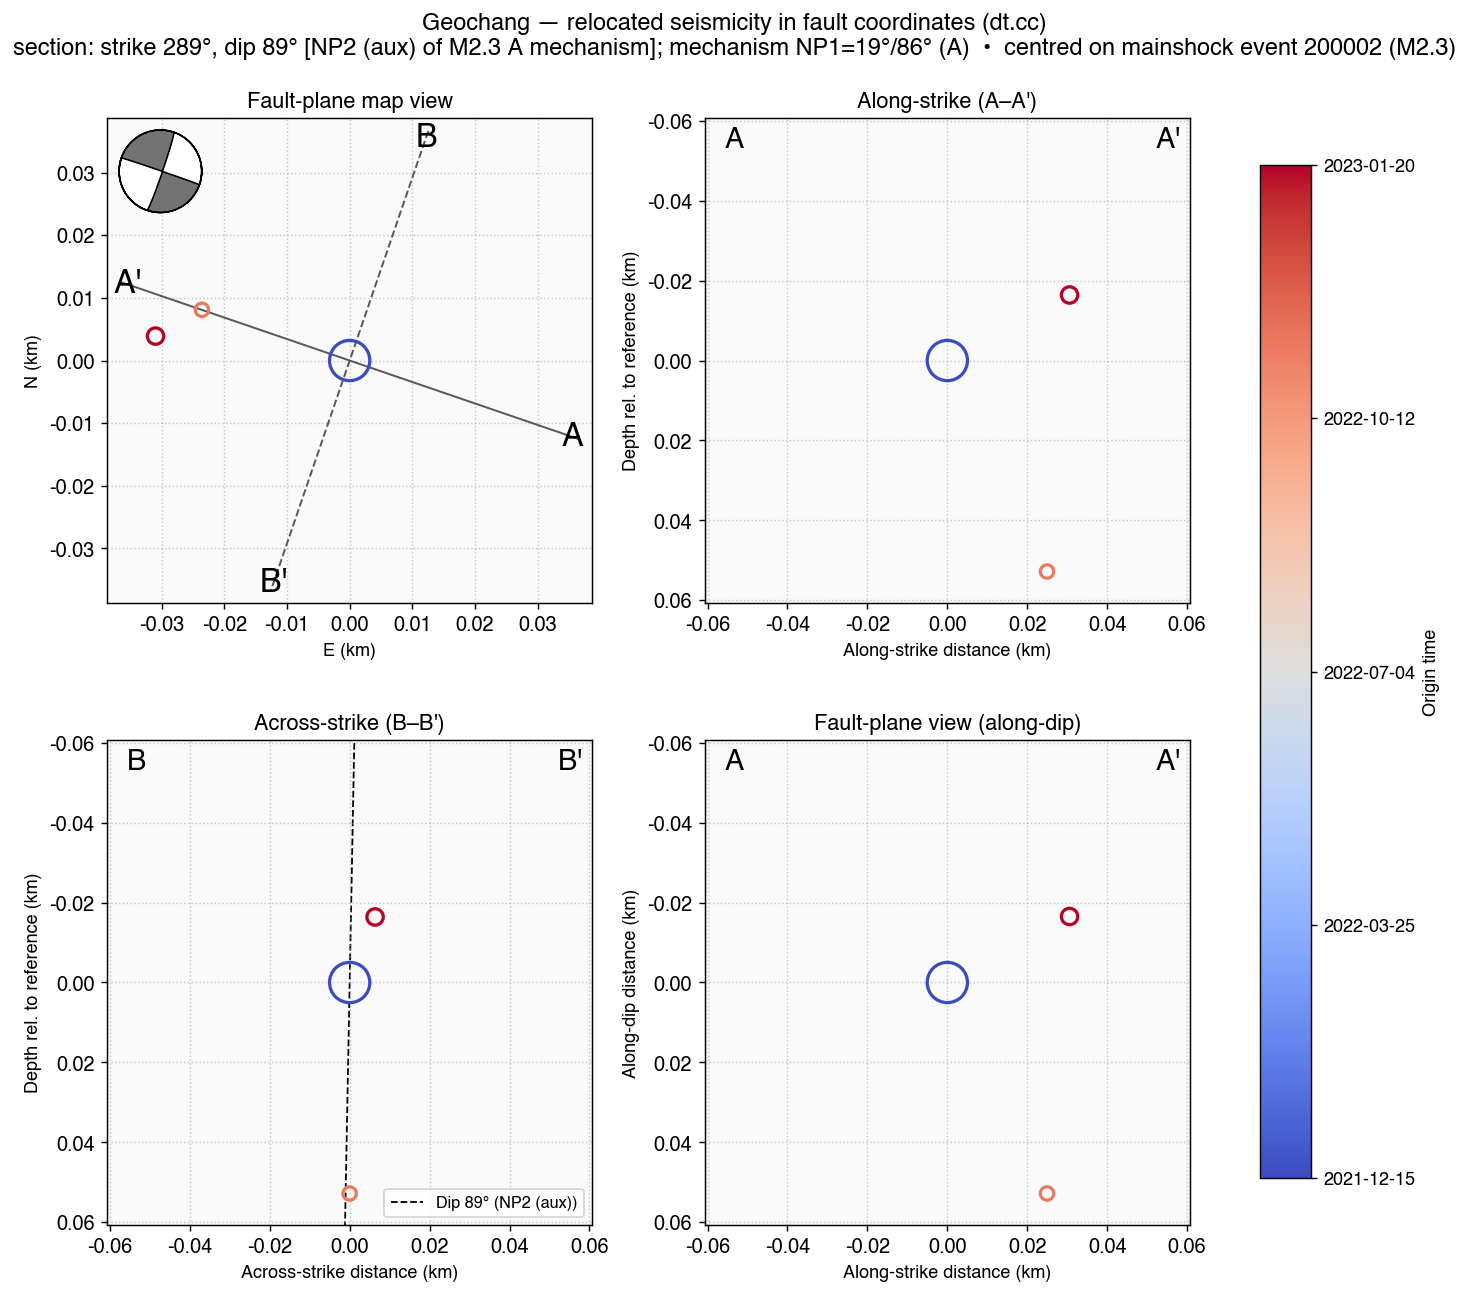

=== (b) bootstrap diagnostic — drops + 95% error bars ===


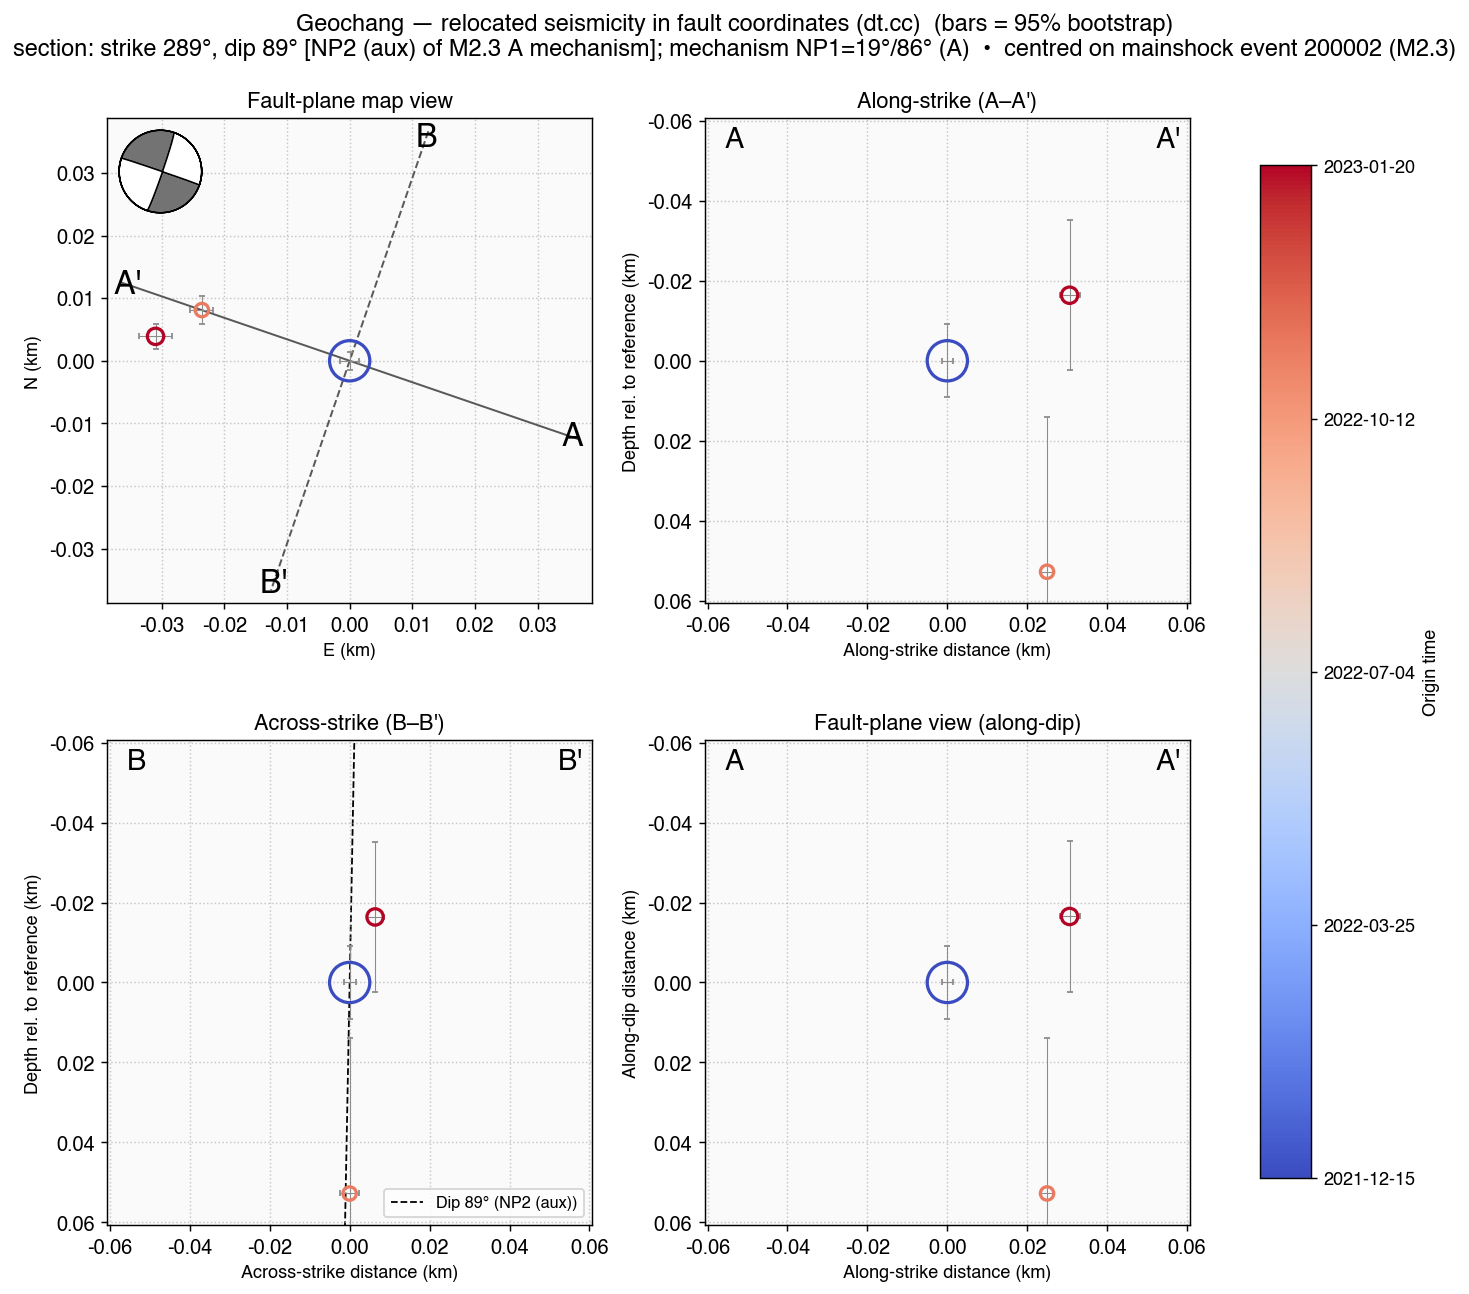

In [14]:
print("=== (a) simple hypoDD.reloc — SOTA default (show_bootstrap=False) ===")
viz.fault_sections(cfg, VELMODEL, frame_from=FRAME_FROM, mech_select=MECH_SELECT); plt.show()
print("=== (b) bootstrap diagnostic — drops + 95% error bars ===")
viz.fault_sections(cfg, VELMODEL, frame_from=FRAME_FROM, mech_select=MECH_SELECT,
                   show_bootstrap=True); plt.show()

### Seismicity time-lapse animation

`animate_seismicity` replays the same 4-panel fault-frame layout as section 4 above
**frame-by-frame in chronological order**: each frame is the cumulative set of events
with origin time ≤ t, where t walks from the cluster's first origin to its last in
~`2·n_events` equal steps (capped at 60 frames). The strike + dip line, beachball, and
dip-line are static (computed once from the full event set); the hypocentre scatter
and clock-in-the-title evolve with t.

Output: an animated GIF saved next to the run outputs and rendered inline in the
notebook via `IPython.display.HTML`. Buyeo's 14-event cluster spans 2022-11-29 →
2026-03-05 (3.3 years) — the time-lapse makes its bursty temporal pattern obvious.

wrote /home/msseo/works/15.PocketQuake/external/korea-cluster-relocation/pipeline/runs/geochang/geochang_seismicity.gif  (8 frames at 4 fps, 2.0 s)


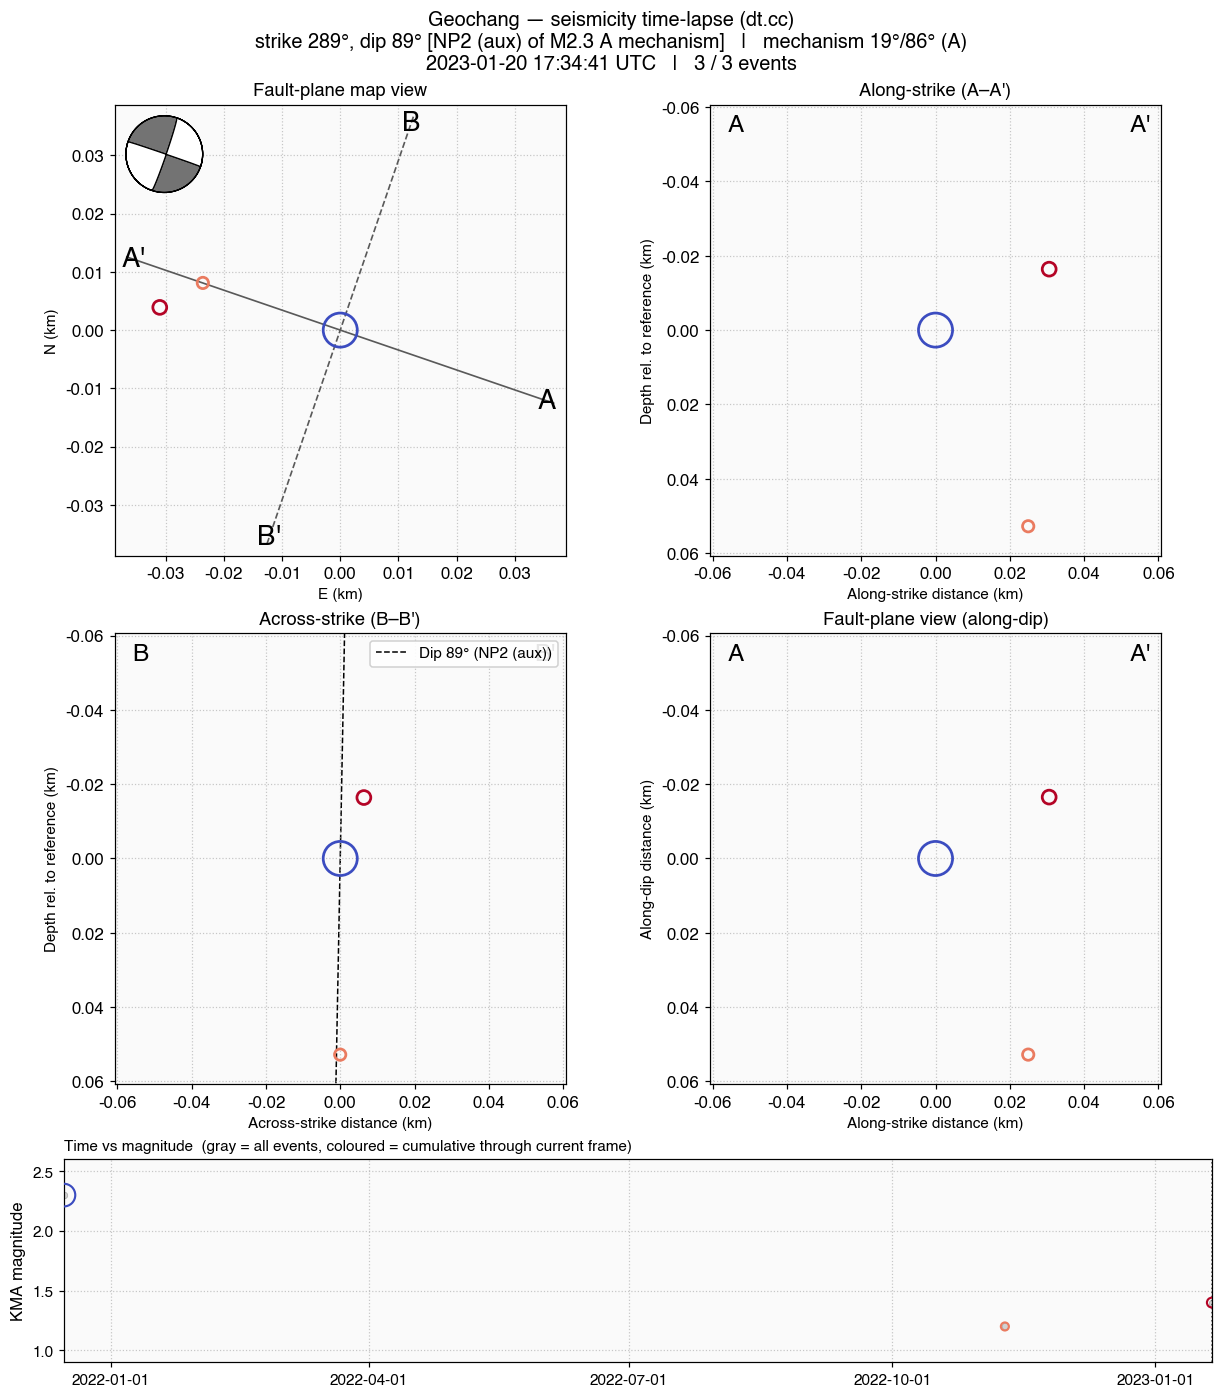

In [15]:
# 4-panel cumulative time-lapse in the same fault frame as section 4
from IPython.display import HTML
_anim = viz.animate_seismicity(cfg, VELMODEL, frame_from=FRAME_FROM, mech_select=MECH_SELECT,
                                return_html=True)
_anim    # inline HTML5 player; the GIF also sits at <output_root>/<cluster>_seismicity.gif

## 5. Seismicity in 3-D (interactive)

`plot_3d_plane` returns an **interactive plotly** 3-D view of the dt.cc hypocentres (relative E–N–depth km,
coloured by origin time, sized by magnitude) with the SVD best-fit fault plane overlaid as a translucent
patch — rotate/zoom to judge planarity and dip. (Interactivity is live in a running notebook; committed
notebooks are output-stripped, and a static export needs the optional `kaleido` package.)

In [16]:
fig3d = viz.plot_3d_plane(cfg, VELMODEL, frame_from=FRAME_FROM, mech_select=MECH_SELECT)
try:                                  # optional static export (needs kaleido); harmless if absent
    fig3d.write_image(f"/tmp/{CLUSTER}_3d.png", scale=2)
except Exception as _e:
    print("(static export skipped — install kaleido for a PNG; the figure is interactive in a live notebook)")
fig3d                                 # <- interactive in JupyterLab: drag to rotate, scroll to zoom

(static export skipped — install kaleido for a PNG; the figure is interactive in a live notebook)


The same view with the per-event uncertainty drawn as a **95% bootstrap error ellipsoid**
(`error="ellipsoid"`) instead of whisker bars: each ellipsoid's shape is the bootstrap sample covariance
and its size the empirical 95% Mahalanobis radius (95% of replicas inside), coloured like its hypocentre.
Tight horizontal but loose depth control shows up as a vertically elongated ellipsoid.

In [17]:
fig3d_e = viz.plot_3d_plane(cfg, VELMODEL, error="ellipsoid", frame_from=FRAME_FROM, mech_select=MECH_SELECT)
try:
    fig3d_e.write_image(f"/tmp/{CLUSTER}_3d_ellipsoid.png", scale=2)
except Exception:
    pass
fig3d_e

## 6. PhaseNet+ polarity quality — are the first motions trustworthy?

The focal mechanisms rest on PhaseNet+ first-motion **polarities**, so it's worth asking how good they are.
`polarity_quality` shows the polarity **confidence** (`|polarity|`) and pick-probability distributions, plus
the SKHASH **polarity misfit** per event (the fraction of polarities inconsistent with the fitted
double-couple — lower = more self-consistent). Where manual picks exist (Gwangyang), `polarity_vs_manual`
compares the PhaseNet+ polarity sign to the first-motion sign read at the **manual** P pick, as a function of
confidence (a ground-truth-free proxy: an analyst reads the raw first swing).

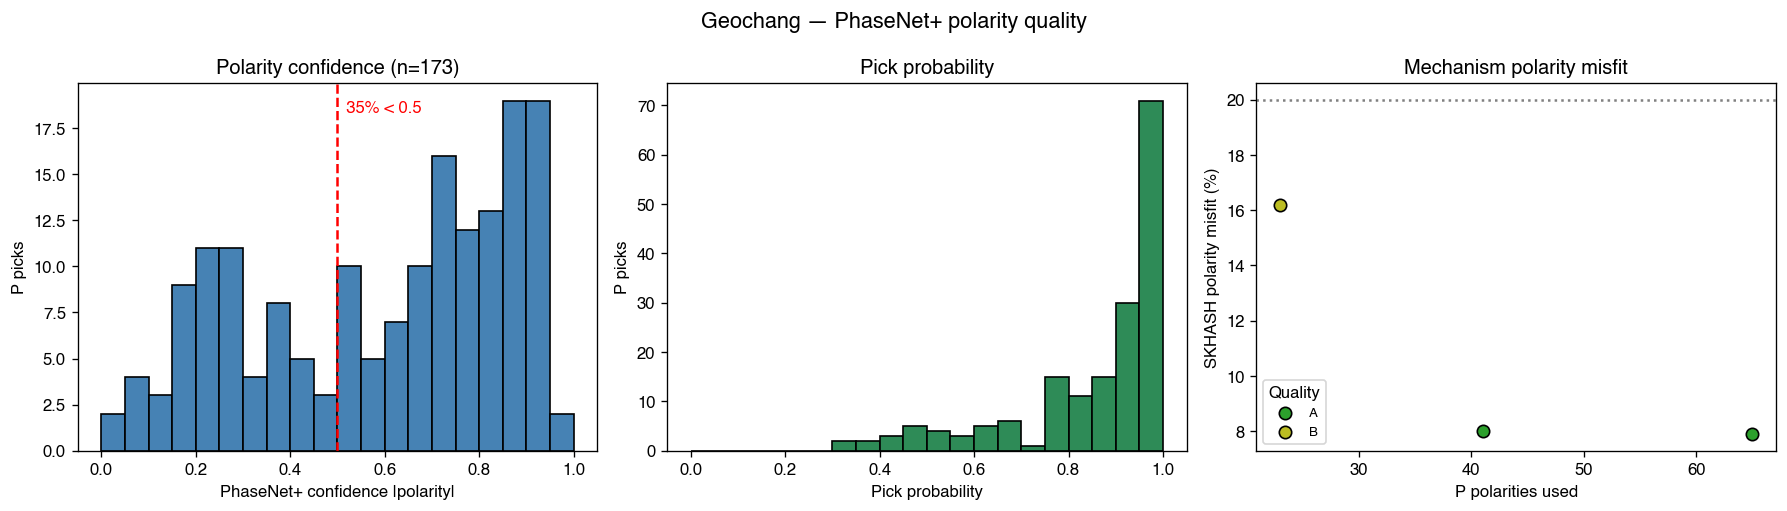

In [18]:
viz.polarity_quality(cfg, VELMODEL); plt.show()

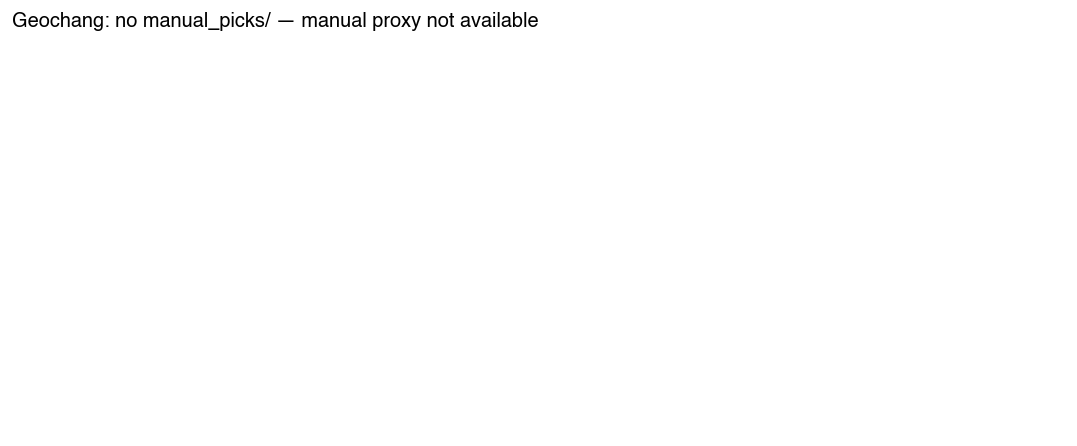

In [19]:
viz.polarity_vs_manual(cfg); plt.show()   # Gwangyang: manual proxy; other clusters: graceful note

**Verdict (Gwangyang, the manual-pick cluster).** PhaseNet+ polarity agreement with the manual
first-motion proxy rises monotonically with the model's own confidence — ~50% at `|pol|`<0.3 (coin-flip),
~60% at 0.3–0.6, ~80% at `|pol|`≥0.6 (and the crude proxy makes 80% a *lower bound*). About **60% of P picks
carry low confidence** (`|pol|`<0.5), while pick *timing* probability is high — i.e. PhaseNet+ is confident
about *when* but often unsure about *up/down*. So the polarities are a **useful automated input for focal
mechanisms when confidence-gated** (the pipeline already gates on `fm_min_pick_prob` and
`fm_min_polarity_weight`), reproducing coherent A/B mechanisms (SKHASH misfit ~11–22%) — but they are **not a
wholesale substitute for expert manual polarity picking**, especially for sparse / low-SNR events; the
low-confidence picks should be down-weighted or excluded, not trusted blindly.

## 7. Interpretation

- **Quality A/B** = well-constrained ("fairly high confidence"); C/D are under-constrained and shown
  for context only. SKHASH grades on polarity misfit, station-distribution ratio, azimuthal/takeoff
  gaps, and mechanism probability.
- **Polarity** (vertical first motion) is the robust signal; the vertical-component **S/P ratio** is a
  secondary enhancement (`cfg.fm_use_sp_ratio`). Re-run with `fm_use_sp_ratio=False` for a
  polarity-only comparison.
- Consistent beachballs across events indicate a coherent source process on a common fault geometry.
- **Fault frame vs mechanism.** The section orientation is the relocation cloud's own best-fit plane,
  and the focal mechanism is overlaid for comparison. When the two agree (e.g. Gwangyang, where the
  best-fit strike ≈ the mechanism's nodal plane), the fault geometry is well determined. When they
  disagree, read the section's strike/dip header: an under-constrained cluster (e.g. **Jangsung** — only
  a few dt.cc events and a grade-D mechanism) still gets a data-driven fault frame, but the mechanism is
  not reliable there, so the section is indicative only.
- To regenerate: run `picking` (`--picker phasenet_plus`), `hypoinverse`, then the `focal_mechanism`
  stage for this cluster (see the top-level README).